# AquaPlant — Phase I: Integrated Failure & Reliability Analysis

This is the **final experimental phase**.

Phase I does not train another model. Instead, it integrates evidence from:

- **Phase D:** clean locked-Test performance and errors
- **Phase E:** corruption robustness
- **Phase F:** calibration and uncertainty
- **Phase G:** selective prediction / abstention
- **Phase H:** Grad-CAM explainability

## Main goal

Answer:

> **What failure modes remain, which failures can be detected by uncertainty, which survive selective prediction, and what visual evidence accompanies them?**

## Required Kaggle inputs

Attach these five artifact datasets/ZIPs:

1. `AquaPlant_PhaseD_Locked_Test_Artifacts.zip`
2. `AquaPlant_PhaseE_Robustness_Artifacts.zip`
3. `AquaPlant_PhaseF_Calibration_Uncertainty_Artifacts.zip`
4. `AquaPlant_PhaseG_Selective_Prediction_Artifacts.zip`
5. `AquaPlant_PhaseH_GradCAM_Explainability_Artifacts.zip`

### Important
- **CPU is enough.**
- No image dataset or model checkpoints are required.
- No training, tuning, or new model inference is performed.
- Phase I only integrates already-frozen experimental outputs.

In [1]:
# ============================================================
# CELL 1 — ENVIRONMENT
# ============================================================

import os
import re
import json
import math
import shutil
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

warnings.filterwarnings("ignore")

EXPECTED_TEST_IMAGES = 157

MODEL_NAMES = [
    "ResNet50_Finetuned",
    "EfficientNetB0_Finetuned",
]

COVERAGE_LEVELS = [
    1.00,
    0.95,
    0.90,
    0.80,
    0.70,
]

HIGH_CONF_THRESHOLD = 0.95
MODERATE_CONF_THRESHOLD = 0.80

print("=" * 82)
print("PHASE I — INTEGRATED FAILURE & RELIABILITY ANALYSIS")
print("=" * 82)

print("\nKaggle inputs:")
for item in os.listdir("/kaggle/input"):
    print(" -", item)

print("\n✅ Phase I environment ready")
print("✅ CPU-only analysis is sufficient")
print("🔒 No model training, tuning, or inference will be performed")


PHASE I — INTEGRATED FAILURE & RELIABILITY ANALYSIS

Kaggle inputs:
 - datasets

✅ Phase I environment ready
✅ CPU-only analysis is sufficient
🔒 No model training, tuning, or inference will be performed


In [2]:
# ============================================================
# CELL 2 — FIND / EXTRACT PHASE D–H ARTIFACTS
# ============================================================

EXTRACT_ROOT = (
    "/kaggle/working/"
    "phaseI_extracted_artifacts"
)

os.makedirs(
    EXTRACT_ROOT,
    exist_ok=True
)

def collect_files(root):
    found = []

    for current_root, dirs, files in os.walk(root):
        for file in files:
            found.append(
                os.path.join(
                    current_root,
                    file
                )
            )

    return found

def extract_candidate_zips():
    input_files = collect_files(
        "/kaggle/input"
    )

    for path in input_files:
        if not path.lower().endswith(
            ".zip"
        ):
            continue

        target = os.path.join(
            EXTRACT_ROOT,
            Path(path).stem
        )

        os.makedirs(
            target,
            exist_ok=True
        )

        try:
            with zipfile.ZipFile(
                path,
                "r"
            ) as z:
                z.extractall(
                    target
                )
        except Exception:
            pass

extract_candidate_zips()

ALL_FILES = (
    collect_files(
        "/kaggle/input"
    )
    + collect_files(
        EXTRACT_ROOT
    )
)

def find_exact_file(filename):
    target = filename.lower()

    matches = [
        path
        for path in ALL_FILES
        if os.path.basename(
            path
        ).lower() == target
    ]

    return (
        matches[0]
        if matches
        else None
    )

REQUIRED_FILES = {
    # Phase D
    "D_summary":
        "phaseD_clean_test_summary.csv",

    "D_resnet_predictions":
        "ResNet50_Finetuned_test_predictions.csv",

    "D_effnet_predictions":
        "EfficientNetB0_Finetuned_test_predictions.csv",

    # Phase E
    "E_overall":
        "phaseE_overall_robustness_summary.csv",

    "E_strong":
        "phaseE_strong_severity_summary.csv",

    "E_corruption":
        "phaseE_corruption_summary.csv",

    # Phase F
    "F_calibration":
        "phaseF_calibration_summary.csv",

    "F_uncertainty":
        "phaseF_uncertainty_summary.csv",

    "F_resnet_per_image":
        "phaseF_ResNet50_Finetuned_per_image.csv",

    "F_effnet_per_image":
        "phaseF_EfficientNetB0_Finetuned_per_image.csv",

    # Phase G
    "G_summary":
        "phaseG_selective_prediction_summary.csv",

    "G_fixed_coverage":
        "phaseG_fixed_coverage_results.csv",

    "G_resnet_per_image":
        "phaseG_ResNet50_Finetuned_per_image_scores.csv",

    "G_effnet_per_image":
        "phaseG_EfficientNetB0_Finetuned_per_image_scores.csv",

    "G_aurc":
        "phaseG_aurc_summary.csv",

    # Phase H
    "H_all_errors":
        "phaseH_all_errors_cam_summary.csv",

    "H_summary":
        "phaseH_explainability_summary.csv",

    "H_selected_cases":
        "phaseH_selected_cases.csv",
}

FOUND = {
    key: find_exact_file(
        filename
    )
    for key, filename
    in REQUIRED_FILES.items()
}

print("=" * 82)
print("ARTIFACT DETECTION")
print("=" * 82)

for key, filename in REQUIRED_FILES.items():
    status = (
        "✅"
        if FOUND[key] is not None
        else "❌"
    )

    print(
        f"{status} {key:24s} "
        f"-> {FOUND[key]}"
    )

missing = [
    key
    for key, path
    in FOUND.items()
    if path is None
]

assert not missing, (
    "❌ Missing required Phase-I inputs: "
    + ", ".join(missing)
)

print(
    "\n✅ All required Phase D–H artifacts found"
)


ARTIFACT DETECTION
✅ D_summary                -> /kaggle/input/datasets/srabondcosta/aquatic-phases/AquaPlant_PhaseD_Locked_Test_Artifacts/phaseD_clean_test_summary.csv
✅ D_resnet_predictions     -> /kaggle/input/datasets/srabondcosta/aquatic-phases/AquaPlant_PhaseD_Locked_Test_Artifacts/ResNet50_Finetuned_test_predictions.csv
✅ D_effnet_predictions     -> /kaggle/input/datasets/srabondcosta/aquatic-phases/AquaPlant_PhaseD_Locked_Test_Artifacts/EfficientNetB0_Finetuned_test_predictions.csv
✅ E_overall                -> /kaggle/input/datasets/srabondcosta/aquatic-phases/AquaPlant_PhaseE_Robustness_Artifacts/phaseE_overall_robustness_summary.csv
✅ E_strong                 -> /kaggle/input/datasets/srabondcosta/aquatic-phases/AquaPlant_PhaseE_Robustness_Artifacts/phaseE_strong_severity_summary.csv
✅ E_corruption             -> /kaggle/input/datasets/srabondcosta/aquatic-phases/AquaPlant_PhaseE_Robustness_Artifacts/phaseE_corruption_summary.csv
✅ F_calibration            -> /kaggle/input/d

In [3]:
# ============================================================
# CELL 3 — LOAD ALL CORE TABLES
# ============================================================

D_summary = pd.read_csv(
    FOUND["D_summary"]
)

D_predictions = {
    "ResNet50_Finetuned":
        pd.read_csv(
            FOUND[
                "D_resnet_predictions"
            ]
        ),

    "EfficientNetB0_Finetuned":
        pd.read_csv(
            FOUND[
                "D_effnet_predictions"
            ]
        ),
}

E_overall = pd.read_csv(
    FOUND["E_overall"]
)

E_strong = pd.read_csv(
    FOUND["E_strong"]
)

E_corruption = pd.read_csv(
    FOUND["E_corruption"]
)

F_calibration = pd.read_csv(
    FOUND["F_calibration"]
)

F_uncertainty = pd.read_csv(
    FOUND["F_uncertainty"]
)

F_per_image = {
    "ResNet50_Finetuned":
        pd.read_csv(
            FOUND[
                "F_resnet_per_image"
            ]
        ),

    "EfficientNetB0_Finetuned":
        pd.read_csv(
            FOUND[
                "F_effnet_per_image"
            ]
        ),
}

G_summary = pd.read_csv(
    FOUND["G_summary"]
)

G_fixed_coverage = pd.read_csv(
    FOUND["G_fixed_coverage"]
)

G_aurc = pd.read_csv(
    FOUND["G_aurc"]
)

G_per_image = {
    "ResNet50_Finetuned":
        pd.read_csv(
            FOUND[
                "G_resnet_per_image"
            ]
        ),

    "EfficientNetB0_Finetuned":
        pd.read_csv(
            FOUND[
                "G_effnet_per_image"
            ]
        ),
}

H_all_errors = pd.read_csv(
    FOUND["H_all_errors"]
)

H_summary = pd.read_csv(
    FOUND["H_summary"]
)

H_selected_cases = pd.read_csv(
    FOUND["H_selected_cases"]
)

print("✅ Core tables loaded")

print("\nPhase D summary:")
display(
    D_summary[
        D_summary["Model"].isin(
            MODEL_NAMES
        )
    ].round(6)
)

print("\nPhase E strong severity:")
display(
    E_strong.round(6)
)

print("\nPhase F calibration:")
display(
    F_calibration.round(6)
)

print("\nPhase G summary:")
display(
    G_summary.round(6)
)

print("\nPhase H summary:")
display(
    H_summary.round(6)
)


✅ Core tables loaded

Phase D summary:


,Rank,Model,Test Accuracy (%),Macro Precision (%),Macro Recall (%),Macro-F1 (%),Weighted-F1 (%),Macro ROC-AUC,Parameters (M),Checkpoint Size (MB),Inference (ms/image)
1,2,ResNet50_Finetuned,96.178344,96.282051,95.909091,95.896478,96.193705,0.999478,23.536718,204.512908,2.818019
2,3,EfficientNetB0_Finetuned,95.541401,95.518371,95.194805,95.205364,95.496588,0.997386,4.025482,39.924754,1.418113



Phase E strong severity:


,Model,Accuracy (%),Macro-F1 (%),Macro-F1 Drop (pp)
0,EfficientNetB0_Finetuned,83.121019,83.398765,11.806599
1,ResNet50_Finetuned,91.719745,91.523876,4.372603



Phase F calibration:


,Model,Temperature,Accuracy (%),Macro-F1 (%),ECE Before,ECE After,ECE Change,NLL Before,NLL After,NLL Change,Brier Before,Brier After,Brier Change,Confidence Before (%),Confidence After (%),Confidence Gap Before (pp),Confidence Gap After (pp),Error-detection AUROC Before,Error-detection AUROC After
0,ResNet50_Finetuned,0.445357,96.178344,95.896478,0.103117,0.029997,-0.073120,0.215756,0.153194,-0.062562,0.085945,0.066741,-0.019204,86.864460,96.125007,-9.313884,-0.053337,0.931567,0.947020
1,EfficientNetB0_Finetuned,0.587467,95.541401,95.205364,0.056961,0.042930,-0.014032,0.195956,0.193310,-0.002645,0.076444,0.067658,-0.008786,91.605556,96.475452,-3.935845,0.934051,0.907619,0.906667



Phase G summary:


,Model,Full-Coverage Accuracy (%),Total Test Errors,Mean Calibrated Confidence (%),Mean Predictive Entropy,Confidence AURC,Confidence E-AURC,Entropy AURC,Entropy E-AURC,Accuracy at ~90% Coverage (%),Risk at ~90% Coverage (%),Error Rejection at ~90% Coverage (%),Accuracy at ~80% Coverage (%),Risk at ~80% Coverage (%),Error Rejection at ~80% Coverage (%)
0,ResNet50_Finetuned,96.178344,6,96.125003,0.109703,0.003375,0.002514,0.003035,0.002174,99.295775,0.704225,83.333333,99.206349,0.793651,83.333333
1,EfficientNetB0_Finetuned,95.541401,7,96.475453,0.108040,0.005918,0.004767,0.005963,0.004812,97.887324,2.112676,57.142857,99.206349,0.793651,85.714286



Phase H summary:


,Model,Total visualized selected cases,Total Test errors explained,Selected correct mean confidence,Selected error mean confidence,Selected correct mean pred-CAM concentration50,Selected error mean pred-CAM concentration50,All errors mean pred-CAM concentration50,All errors mean true-CAM concentration50
0,ResNet50_Finetuned,6,6,0.730421,0.882418,0.165537,0.149952,0.128322,0.120194
1,EfficientNetB0_Finetuned,6,7,0.731145,0.988209,0.242357,0.284698,0.221378,0.239283


In [4]:
# ============================================================
# CELL 4 — CROSS-PHASE CONSISTENCY CHECKS
# ============================================================

def model_row(
    df,
    model_name
):
    rows = df[
        df["Model"]
        == model_name
    ]

    assert len(rows) == 1, (
        f"Expected one row for "
        f"{model_name}, got {len(rows)}"
    )

    return rows.iloc[0]

for model_name in MODEL_NAMES:
    d = model_row(
        D_summary,
        model_name
    )

    e = model_row(
        E_overall,
        model_name
    )

    f = model_row(
        F_calibration,
        model_name
    )

    g = model_row(
        G_summary,
        model_name
    )

    h = model_row(
        H_summary,
        model_name
    )

    # Clean accuracy must remain identical
    # throughout D -> E -> F -> G.
    assert np.isclose(
        d["Test Accuracy (%)"],
        e["Clean Accuracy (%)"],
        atol=1e-8
    )

    assert np.isclose(
        d["Test Accuracy (%)"],
        f["Accuracy (%)"],
        atol=1e-8
    )

    assert np.isclose(
        d["Test Accuracy (%)"],
        g["Full-Coverage Accuracy (%)"],
        atol=1e-8
    )

    # Clean Macro-F1 must remain identical
    # through D -> E -> F.
    assert np.isclose(
        d["Macro-F1 (%)"],
        e["Clean Macro-F1 (%)"],
        atol=1e-8
    )

    assert np.isclose(
        d["Macro-F1 (%)"],
        f["Macro-F1 (%)"],
        atol=1e-8
    )

    expected_errors = int(
        g["Total Test Errors"]
    )

    h_errors = int(
        h["Total Test errors explained"]
    )

    assert (
        expected_errors
        == h_errors
    )

    assert (
        len(
            G_per_image[
                model_name
            ]
        )
        == EXPECTED_TEST_IMAGES
    )

    print(
        f"✅ {model_name}: "
        "cross-phase metrics consistent"
    )

print(
    "\n✅ Phase D–H consistency verification PASSED"
)


✅ ResNet50_Finetuned: cross-phase metrics consistent
✅ EfficientNetB0_Finetuned: cross-phase metrics consistent

✅ Phase D–H consistency verification PASSED


In [5]:
# ============================================================
# CELL 5 — HELPER FUNCTIONS
# ============================================================

def image_key(path):
    path = str(
        path
    ).replace(
        "\\",
        "/"
    )

    parts = [
        p
        for p in path.split("/")
        if p
    ]

    if len(parts) >= 2:
        return (
            parts[-2].lower()
            + "/"
            + parts[-1].lower()
        )

    return path.lower()

def pretty_class(name):
    text = str(
        name
    )

    text = re.sub(
        r"^Class_\d+_",
        "",
        text,
        flags=re.IGNORECASE
    )

    text = text.replace(
        "_",
        " "
    )

    text = text.replace(
        "-",
        " "
    )

    return " ".join(
        word.capitalize()
        for word in text.split()
    )

def parse_bool_series(series):
    if series.dtype == bool:
        return series

    return (
        series.astype(str)
        .str.lower()
        .map({
            "true": True,
            "false": False,
            "1": True,
            "0": False,
        })
    )

def confidence_band(value):
    if value >= HIGH_CONF_THRESHOLD:
        return "High (>=0.95)"

    if value >= MODERATE_CONF_THRESHOLD:
        return "Moderate (0.80-0.95)"

    return "Lower (<0.80)"

def coverage_acceptance(
    rank,
    coverage,
    n=EXPECTED_TEST_IMAGES
):
    k = int(
        np.ceil(
            coverage
            * n
        )
    )

    return (
        int(rank)
        <= k
    )

print("✅ Helper functions ready")


✅ Helper functions ready


In [6]:
# ============================================================
# CELL 6 — BUILD UNIFIED PER-ERROR TABLE
# ============================================================

unified_error_parts = []

for model_name in MODEL_NAMES:
    g_df = (
        G_per_image[
            model_name
        ]
        .copy()
    )

    g_df["correct"] = (
        parse_bool_series(
            g_df["correct"]
        )
    )

    assert (
        g_df["correct"]
        .notna()
        .all()
    )

    errors = (
        g_df[
            ~g_df["correct"]
        ]
        .copy()
    )

    errors[
        "Model"
    ] = model_name

    errors[
        "image_key"
    ] = errors[
        "image_path"
    ].apply(
        image_key
    )

    errors[
        "true_class_pretty"
    ] = errors[
        "true_class"
    ].apply(
        pretty_class
    )

    errors[
        "pred_class_pretty"
    ] = errors[
        "pred_class"
    ].apply(
        pretty_class
    )

    errors[
        "confusion_pair"
    ] = (
        errors[
            "true_class_pretty"
        ]
        + " -> "
        + errors[
            "pred_class_pretty"
        ]
    )

    errors[
        "confidence_band"
    ] = errors[
        "calibrated_confidence"
    ].apply(
        confidence_band
    )

    for coverage in [
        0.95,
        0.90,
        0.80,
        0.70,
    ]:
        label = int(
            coverage
            * 100
        )

        errors[
            f"accepted_at_{label}pct_coverage"
        ] = errors[
            "confidence_rank"
        ].apply(
            lambda rank: coverage_acceptance(
                rank,
                coverage
            )
        )

        errors[
            f"rejected_at_{label}pct_coverage"
        ] = ~errors[
            f"accepted_at_{label}pct_coverage"
        ]

    # Merge Phase-F before/after confidence and entropy.
    f_df = (
        F_per_image[
            model_name
        ]
        .copy()
    )

    f_df[
        "image_key"
    ] = f_df[
        "image_path"
    ].apply(
        image_key
    )

    f_keep = f_df[
        [
            "image_key",
            "confidence_before",
            "confidence_after",
            "entropy_before",
            "entropy_after",
        ]
    ].copy()

    errors = errors.merge(
        f_keep,
        on="image_key",
        how="left"
    )

    # Merge Phase-H Grad-CAM descriptors.
    h_df = (
        H_all_errors[
            H_all_errors["Model"]
            == model_name
        ]
        .copy()
    )

    h_df[
        "image_key"
    ] = h_df[
        "image_path"
    ].apply(
        image_key
    )

    h_keep = h_df[
        [
            "image_key",
            "error_rank_by_confidence",
            "pred_CAM_concentration50",
            "true_CAM_concentration50",
        ]
    ].copy()

    errors = errors.merge(
        h_keep,
        on="image_key",
        how="left"
    )

    assert (
        errors[
            "pred_CAM_concentration50"
        ]
        .notna()
        .all()
    )

    unified_error_parts.append(
        errors
    )

unified_errors = pd.concat(
    unified_error_parts,
    ignore_index=True
)

assert len(
    unified_errors
) == 13

print(
    "✅ Unified error table created:",
    len(unified_errors),
    "model-error records"
)

display(
    unified_errors[
        [
            "Model",
            "image_key",
            "true_class_pretty",
            "pred_class_pretty",
            "calibrated_confidence",
            "predictive_entropy",
            "confidence_band",
            "accepted_at_90pct_coverage",
            "pred_CAM_concentration50",
            "true_CAM_concentration50",
        ]
    ].sort_values(
        [
            "Model",
            "calibrated_confidence",
        ],
        ascending=[
            True,
            False,
        ]
    ).round(6)
)


✅ Unified error table created: 13 model-error records


,Model,image_key,true_class_pretty,pred_class_pretty,calibrated_confidence,predictive_entropy,confidence_band,accepted_at_90pct_coverage,pred_CAM_concentration50,true_CAM_concentration50
7,EfficientNetB0_Finetuned,class_10_lippia_alba/image_712.jpg,Lippia Alba,Chinese Water Spinach,0.998927,0.009621,High (>=0.95),True,0.267080,0.241012
6,EfficientNetB0_Finetuned,class_10_lippia_alba/image_708.jpg,Lippia Alba,Chinese Water Spinach,0.977491,0.109981,High (>=0.95),True,0.302316,0.344428
12,EfficientNetB0_Finetuned,class_9_mexican_sword_lily/image_622.jpg,Mexican Sword Lily,Water Plantain,0.956778,0.250095,High (>=0.95),True,0.138512,0.173430
8,EfficientNetB0_Finetuned,class_11_marsilea_minuta/image_793.jpg,Marsilea Minuta,Water Popy,0.524588,1.494519,Lower (<0.80),False,0.239577,0.128986
10,EfficientNetB0_Finetuned,class_1_water_iris/image_37.jpg,Water Iris,Mexican Sword Lily,0.480736,0.971571,Lower (<0.80),False,0.066087,0.217096
11,EfficientNetB0_Finetuned,class_7_chinese_water_spinach/image_493.jpg,Chinese Water Spinach,Lippia Alba,0.464403,1.410345,Lower (<0.80),False,0.230210,0.257215
9,EfficientNetB0_Finetuned,class_11_marsilea_minuta/image_813.jpg,Marsilea Minuta,Salvania,0.445433,1.159721,Lower (<0.80),False,0.305863,0.312819
0,ResNet50_Finetuned,class_10_lippia_alba/image_708.jpg,Lippia Alba,Chinese Water Spinach,0.989679,0.062557,High (>=0.95),True,0.215541,0.155652
4,ResNet50_Finetuned,class_7_chinese_water_spinach/image_493.jpg,Chinese Water Spinach,Water Iris,0.775157,0.618562,Lower (<0.80),False,0.084363,0.139489
3,ResNet50_Finetuned,class_2_pistia_stratiotes/image_75.jpg,Pistia Stratiotes,Lippia Alba,0.755275,0.674488,Lower (<0.80),False,0.114557,0.106724


In [7]:
# ============================================================
# CELL 7 — IDENTIFY SHARED ERRORS + RECURRENT CONFUSIONS
# ============================================================

error_models_per_image = (
    unified_errors
    .groupby(
        "image_key"
    )["Model"]
    .nunique()
)

shared_image_keys = set(
    error_models_per_image[
        error_models_per_image
        >= 2
    ].index
)

unified_errors[
    "shared_error_across_models"
] = unified_errors[
    "image_key"
].isin(
    shared_image_keys
)

pair_counts = (
    unified_errors
    .groupby(
        "confusion_pair"
    )
    .size()
)

recurrent_pairs = set(
    pair_counts[
        pair_counts >= 2
    ].index
)

unified_errors[
    "recurrent_confusion_pair"
] = unified_errors[
    "confusion_pair"
].isin(
    recurrent_pairs
)

def build_failure_tags(row):
    tags = []

    if row[
        "shared_error_across_models"
    ]:
        tags.append(
            "Shared cross-model hard sample"
        )

    if row[
        "recurrent_confusion_pair"
    ]:
        tags.append(
            "Recurrent class-confusion pair"
        )

    if row[
        "calibrated_confidence"
    ] >= HIGH_CONF_THRESHOLD:
        tags.append(
            "High-confidence error"
        )

    if row[
        "accepted_at_90pct_coverage"
    ]:
        tags.append(
            "Survives ~90% selective coverage"
        )
    else:
        tags.append(
            "Rejected by ~90% selective coverage"
        )

    if not tags:
        tags.append(
            "Architecture-specific error"
        )

    return "; ".join(
        tags
    )

unified_errors[
    "failure_tags"
] = unified_errors.apply(
    build_failure_tags,
    axis=1
)

UNIFIED_ERRORS_PATH = (
    "/kaggle/working/"
    "phaseI_unified_error_table.csv"
)

unified_errors.to_csv(
    UNIFIED_ERRORS_PATH,
    index=False
)

print(
    "Shared hard images:",
    len(shared_image_keys)
)

print(
    "Recurrent confusion pairs:",
    len(recurrent_pairs)
)

print(
    "\n✅ Saved:",
    UNIFIED_ERRORS_PATH
)

display(
    unified_errors[
        [
            "Model",
            "image_key",
            "confusion_pair",
            "calibrated_confidence",
            "predictive_entropy",
            "shared_error_across_models",
            "recurrent_confusion_pair",
            "failure_tags",
        ]
    ].sort_values(
        "calibrated_confidence",
        ascending=False
    ).round(6)
)


Shared hard images: 3
Recurrent confusion pairs: 2

✅ Saved: /kaggle/working/phaseI_unified_error_table.csv


,Model,image_key,confusion_pair,calibrated_confidence,predictive_entropy,shared_error_across_models,recurrent_confusion_pair,failure_tags
7,EfficientNetB0_Finetuned,class_10_lippia_alba/image_712.jpg,Lippia Alba -> Chinese Water Spinach,0.998927,0.009621,False,True,Recurrent class-confusion pair; High-confidenc...
0,ResNet50_Finetuned,class_10_lippia_alba/image_708.jpg,Lippia Alba -> Chinese Water Spinach,0.989679,0.062557,True,True,Shared cross-model hard sample; Recurrent clas...
6,EfficientNetB0_Finetuned,class_10_lippia_alba/image_708.jpg,Lippia Alba -> Chinese Water Spinach,0.977491,0.109981,True,True,Shared cross-model hard sample; Recurrent clas...
12,EfficientNetB0_Finetuned,class_9_mexican_sword_lily/image_622.jpg,Mexican Sword Lily -> Water Plantain,0.956778,0.250095,True,True,Shared cross-model hard sample; Recurrent clas...
4,ResNet50_Finetuned,class_7_chinese_water_spinach/image_493.jpg,Chinese Water Spinach -> Water Iris,0.775157,0.618562,True,False,Shared cross-model hard sample; Rejected by ~9...
3,ResNet50_Finetuned,class_2_pistia_stratiotes/image_75.jpg,Pistia Stratiotes -> Lippia Alba,0.755275,0.674488,False,False,Rejected by ~90% selective coverage
2,ResNet50_Finetuned,class_14_kachuripana/image_992.jpg,Kachuripana -> Water Plantain,0.697483,0.968070,False,False,Rejected by ~90% selective coverage
5,ResNet50_Finetuned,class_9_mexican_sword_lily/image_622.jpg,Mexican Sword Lily -> Water Plantain,0.581941,0.992250,True,True,Shared cross-model hard sample; Recurrent clas...
8,EfficientNetB0_Finetuned,class_11_marsilea_minuta/image_793.jpg,Marsilea Minuta -> Water Popy,0.524588,1.494519,False,False,Rejected by ~90% selective coverage
10,EfficientNetB0_Finetuned,class_1_water_iris/image_37.jpg,Water Iris -> Mexican Sword Lily,0.480736,0.971571,False,False,Rejected by ~90% selective coverage


In [8]:
# ============================================================
# CELL 8 — SHARED HARD-SAMPLE SUMMARY
# ============================================================

shared_rows = []

for key in sorted(
    shared_image_keys
):
    group = unified_errors[
        unified_errors[
            "image_key"
        ] == key
    ].copy()

    shared_rows.append({
        "image_key":
            key,

        "true_class":
            " | ".join(
                sorted(
                    group[
                        "true_class_pretty"
                    ].unique()
                )
            ),

        "models_failing":
            " | ".join(
                sorted(
                    group[
                        "Model"
                    ].unique()
                )
            ),

        "predictions":
            " | ".join(
                (
                    group["Model"]
                    + ": "
                    + group[
                        "pred_class_pretty"
                    ]
                ).tolist()
            ),

        "mean_calibrated_confidence":
            group[
                "calibrated_confidence"
            ].mean(),

        "max_calibrated_confidence":
            group[
                "calibrated_confidence"
            ].max(),

        "mean_predictive_entropy":
            group[
                "predictive_entropy"
            ].mean(),

        "both_survive_90pct_coverage":
            bool(
                group[
                    "accepted_at_90pct_coverage"
                ].all()
            ),

        "any_survives_90pct_coverage":
            bool(
                group[
                    "accepted_at_90pct_coverage"
                ].any()
            ),
    })

shared_errors_df = pd.DataFrame(
    shared_rows
)

SHARED_ERRORS_PATH = (
    "/kaggle/working/"
    "phaseI_shared_cross_model_errors.csv"
)

shared_errors_df.to_csv(
    SHARED_ERRORS_PATH,
    index=False
)

display(
    shared_errors_df.round(6)
)

print(
    "\n✅ Saved:",
    SHARED_ERRORS_PATH
)


,image_key,true_class,models_failing,predictions,mean_calibrated_confidence,max_calibrated_confidence,mean_predictive_entropy,both_survive_90pct_coverage,any_survives_90pct_coverage
0,class_10_lippia_alba/image_708.jpg,Lippia Alba,EfficientNetB0_Finetuned | ResNet50_Finetuned,ResNet50_Finetuned: Chinese Water Spinach | Ef...,0.983585,0.989679,0.086269,True,True
1,class_7_chinese_water_spinach/image_493.jpg,Chinese Water Spinach,EfficientNetB0_Finetuned | ResNet50_Finetuned,ResNet50_Finetuned: Water Iris | EfficientNetB...,0.619780,0.775157,1.014453,False,False
2,class_9_mexican_sword_lily/image_622.jpg,Mexican Sword Lily,EfficientNetB0_Finetuned | ResNet50_Finetuned,ResNet50_Finetuned: Water Plantain | Efficient...,0.769360,0.956778,0.621172,False,True



✅ Saved: /kaggle/working/phaseI_shared_cross_model_errors.csv


In [9]:
# ============================================================
# CELL 9 — CONFUSION-PAIR FAILURE SUMMARY
# ============================================================

confusion_summary = (
    unified_errors
    .groupby(
        [
            "true_class_pretty",
            "pred_class_pretty",
        ]
    )
    .agg(
        error_count=(
            "image_key",
            "size"
        ),

        unique_images=(
            "image_key",
            "nunique"
        ),

        models_affected=(
            "Model",
            "nunique"
        ),

        mean_confidence=(
            "calibrated_confidence",
            "mean"
        ),

        max_confidence=(
            "calibrated_confidence",
            "max"
        ),

        mean_entropy=(
            "predictive_entropy",
            "mean"
        ),

        shared_error_records=(
            "shared_error_across_models",
            "sum"
        ),
    )
    .reset_index()
)

confusion_summary[
    "confusion_pair"
] = (
    confusion_summary[
        "true_class_pretty"
    ]
    + " -> "
    + confusion_summary[
        "pred_class_pretty"
    ]
)

confusion_summary = (
    confusion_summary
    .sort_values(
        [
            "error_count",
            "max_confidence",
        ],
        ascending=[
            False,
            False,
        ]
    )
    .reset_index(
        drop=True
    )
)

CONFUSION_SUMMARY_PATH = (
    "/kaggle/working/"
    "phaseI_confusion_pair_summary.csv"
)

confusion_summary.to_csv(
    CONFUSION_SUMMARY_PATH,
    index=False
)

display(
    confusion_summary.round(6)
)

print(
    "\n✅ Saved:",
    CONFUSION_SUMMARY_PATH
)


,true_class_pretty,pred_class_pretty,error_count,unique_images,models_affected,mean_confidence,max_confidence,mean_entropy,shared_error_records,confusion_pair
0,Lippia Alba,Chinese Water Spinach,3,2,2,0.988699,0.998927,0.060719,2,Lippia Alba -> Chinese Water Spinach
1,Mexican Sword Lily,Water Plantain,2,1,2,0.769360,0.956778,0.621172,2,Mexican Sword Lily -> Water Plantain
2,Chinese Water Spinach,Water Iris,1,1,1,0.775157,0.775157,0.618562,1,Chinese Water Spinach -> Water Iris
3,Pistia Stratiotes,Lippia Alba,1,1,1,0.755275,0.755275,0.674488,0,Pistia Stratiotes -> Lippia Alba
4,Kachuripana,Water Plantain,1,1,1,0.697483,0.697483,0.968070,0,Kachuripana -> Water Plantain
5,Marsilea Minuta,Water Popy,1,1,1,0.524588,0.524588,1.494519,0,Marsilea Minuta -> Water Popy
6,Water Iris,Mexican Sword Lily,1,1,1,0.480736,0.480736,0.971571,0,Water Iris -> Mexican Sword Lily
7,Chinese Water Spinach,Lippia Alba,1,1,1,0.464403,0.464403,1.410345,1,Chinese Water Spinach -> Lippia Alba
8,Marsilea Minuta,Salvania,1,1,1,0.445433,0.445433,1.159721,0,Marsilea Minuta -> Salvania
9,Kachuripana,Water Iris,1,1,1,0.394333,0.394333,1.458811,0,Kachuripana -> Water Iris



✅ Saved: /kaggle/working/phaseI_confusion_pair_summary.csv


In [10]:
# ============================================================
# CELL 10 — SELECTIVE-PREDICTION ERROR SURVIVAL
# ============================================================

coverage_rows = []

for model_name in MODEL_NAMES:
    model_df = G_fixed_coverage[
        G_fixed_coverage["Model"]
        == model_name
    ].copy()

    for coverage in COVERAGE_LEVELS:
        row = model_df[
            np.isclose(
                model_df[
                    "Target Coverage"
                ],
                coverage
            )
        ]

        assert len(row) == 1

        row = row.iloc[0]

        coverage_rows.append({
            "Model":
                model_name,

            "Target Coverage (%)":
                coverage * 100,

            "Actual Coverage (%)":
                row[
                    "Actual Coverage"
                ] * 100,

            "Accepted Errors":
                int(
                    row[
                        "Accepted Errors"
                    ]
                ),

            "Rejected Errors":
                int(
                    row[
                        "Rejected Errors"
                    ]
                ),

            "Error Rejection Rate (%)":
                row[
                    "Error Rejection Rate"
                ] * 100,

            "Selective Accuracy (%)":
                row[
                    "Selective Accuracy"
                ] * 100,
        })

error_survival_df = pd.DataFrame(
    coverage_rows
)

ERROR_SURVIVAL_PATH = (
    "/kaggle/working/"
    "phaseI_error_survival_by_coverage.csv"
)

error_survival_df.to_csv(
    ERROR_SURVIVAL_PATH,
    index=False
)

display(
    error_survival_df.round(6)
)

print(
    "\n✅ Saved:",
    ERROR_SURVIVAL_PATH
)


,Model,Target Coverage (%),Actual Coverage (%),Accepted Errors,Rejected Errors,Error Rejection Rate (%),Selective Accuracy (%)
0,ResNet50_Finetuned,100.0,100.000000,6,0,0.000000,96.178344
1,ResNet50_Finetuned,95.0,95.541401,4,2,33.333333,97.333333
2,ResNet50_Finetuned,90.0,90.445860,1,5,83.333333,99.295775
3,ResNet50_Finetuned,80.0,80.254777,1,5,83.333333,99.206349
4,ResNet50_Finetuned,70.0,70.063694,0,6,100.000000,100.000000
5,EfficientNetB0_Finetuned,100.0,100.000000,7,0,0.000000,95.541401
6,EfficientNetB0_Finetuned,95.0,95.541401,3,4,57.142857,98.000000
7,EfficientNetB0_Finetuned,90.0,90.445860,3,4,57.142857,97.887324
8,EfficientNetB0_Finetuned,80.0,80.254777,1,6,85.714286,99.206349
9,EfficientNetB0_Finetuned,70.0,70.063694,1,6,85.714286,99.090909



✅ Saved: /kaggle/working/phaseI_error_survival_by_coverage.csv


In [11]:
# ============================================================
# CELL 11 — CROSS-PHASE MODEL RELIABILITY PROFILE
# ============================================================

profile_rows = []

for model_name in MODEL_NAMES:
    d = model_row(
        D_summary,
        model_name
    )

    e_overall = model_row(
        E_overall,
        model_name
    )

    e_strong = model_row(
        E_strong,
        model_name
    )

    f = model_row(
        F_calibration,
        model_name
    )

    g = model_row(
        G_summary,
        model_name
    )

    h = model_row(
        H_summary,
        model_name
    )

    model_errors = unified_errors[
        unified_errors["Model"]
        == model_name
    ]

    profile_rows.append({
        "Model":
            model_name,

        # Phase D
        "Clean Test Accuracy (%)":
            d[
                "Test Accuracy (%)"
            ],

        "Clean Macro-F1 (%)":
            d[
                "Macro-F1 (%)"
            ],

        "Macro ROC-AUC":
            d[
                "Macro ROC-AUC"
            ],

        # Phase E
        "Mean Corrupted Macro-F1 (%)":
            e_overall[
                "Mean Corrupted Macro-F1 (%)"
            ],

        "Macro-F1 Retention (%)":
            e_overall[
                "Macro-F1 Retention (%)"
            ],

        "Strong-Severity Macro-F1 (%)":
            e_strong[
                "Macro-F1 (%)"
            ],

        "Worst Corrupted Macro-F1 (%)":
            e_overall[
                "Worst Corrupted Macro-F1 (%)"
            ],

        "Worst Corruption":
            e_overall[
                "Worst Corruption"
            ],

        # Phase F
        "ECE Before":
            f[
                "ECE Before"
            ],

        "ECE After":
            f[
                "ECE After"
            ],

        "NLL After":
            f[
                "NLL After"
            ],

        "Brier After":
            f[
                "Brier After"
            ],

        "Confidence Gap After (pp)":
            f[
                "Confidence Gap After (pp)"
            ],

        "Error-detection AUROC After":
            f[
                "Error-detection AUROC After"
            ],

        # Phase G
        "Confidence AURC":
            g[
                "Confidence AURC"
            ],

        "Accuracy at ~90% Coverage (%)":
            g[
                "Accuracy at ~90% Coverage (%)"
            ],

        "Error Rejection at ~90% Coverage (%)":
            g[
                "Error Rejection at ~90% Coverage (%)"
            ],

        # Phase H / I
        "Total Test Errors":
            int(
                g[
                    "Total Test Errors"
                ]
            ),

        "High-confidence Errors (>=0.95)":
            int(
                (
                    model_errors[
                        "calibrated_confidence"
                    ]
                    >= HIGH_CONF_THRESHOLD
                ).sum()
            ),

        "Errors Surviving ~90% Coverage":
            int(
                model_errors[
                    "accepted_at_90pct_coverage"
                ].sum()
            ),

        "Shared Error Records":
            int(
                model_errors[
                    "shared_error_across_models"
                ].sum()
            ),

        "All Errors Mean Pred-CAM Concentration50":
            h[
                "All errors mean pred-CAM concentration50"
            ],

        "All Errors Mean True-CAM Concentration50":
            h[
                "All errors mean true-CAM concentration50"
            ],
    })

model_profile_df = pd.DataFrame(
    profile_rows
)

MODEL_PROFILE_PATH = (
    "/kaggle/working/"
    "phaseI_cross_phase_model_profile.csv"
)

model_profile_df.to_csv(
    MODEL_PROFILE_PATH,
    index=False
)

display(
    model_profile_df.round(6)
)

print(
    "\n✅ Saved:",
    MODEL_PROFILE_PATH
)


,Model,Clean Test Accuracy (%),Clean Macro-F1 (%),Macro ROC-AUC,Mean Corrupted Macro-F1 (%),Macro-F1 Retention (%),Strong-Severity Macro-F1 (%),Worst Corrupted Macro-F1 (%),Worst Corruption,ECE Before,...,Error-detection AUROC After,Confidence AURC,Accuracy at ~90% Coverage (%),Error Rejection at ~90% Coverage (%),Total Test Errors,High-confidence Errors (>=0.95),Errors Surviving ~90% Coverage,Shared Error Records,All Errors Mean Pred-CAM Concentration50,All Errors Mean True-CAM Concentration50
0,ResNet50_Finetuned,96.178344,95.896478,0.999478,92.802053,96.773161,91.523876,89.439844,gaussian_blur,0.103117,...,0.947020,0.003375,99.295775,83.333333,6,1,1,3,0.128322,0.120194
1,EfficientNetB0_Finetuned,95.541401,95.205364,0.997386,90.621526,95.185316,83.398765,64.200953,contrast,0.056961,...,0.906667,0.005918,97.887324,57.142857,7,3,3,3,0.221378,0.239283



✅ Saved: /kaggle/working/phaseI_cross_phase_model_profile.csv


In [12]:
# ============================================================
# CELL 12 — FAILURE TAXONOMY SUMMARY
# ============================================================

taxonomy_rows = []

taxonomy_definitions = {
    "Shared cross-model hard sample":
        (
            "The same Test image is misclassified "
            "by both final architectures."
        ),

    "Recurrent class-confusion pair":
        (
            "The same true-to-predicted class pair "
            "occurs at least twice across final-model errors."
        ),

    "High-confidence error":
        (
            "Incorrect prediction with calibrated "
            "confidence >= 0.95."
        ),

    "Survives ~90% selective coverage":
        (
            "The error remains among the approximately "
            "90% most-confident predictions."
        ),

    "Rejected by ~90% selective coverage":
        (
            "The error falls in the approximately "
            "10% least-confident cases and is abstained."
        ),
}

for taxonomy_name, definition in taxonomy_definitions.items():
    for model_name in MODEL_NAMES:
        model_errors = unified_errors[
            unified_errors["Model"]
            == model_name
        ]

        if taxonomy_name == (
            "Shared cross-model hard sample"
        ):
            mask = model_errors[
                "shared_error_across_models"
            ]

        elif taxonomy_name == (
            "Recurrent class-confusion pair"
        ):
            mask = model_errors[
                "recurrent_confusion_pair"
            ]

        elif taxonomy_name == (
            "High-confidence error"
        ):
            mask = (
                model_errors[
                    "calibrated_confidence"
                ]
                >= HIGH_CONF_THRESHOLD
            )

        elif taxonomy_name == (
            "Survives ~90% selective coverage"
        ):
            mask = model_errors[
                "accepted_at_90pct_coverage"
            ]

        elif taxonomy_name == (
            "Rejected by ~90% selective coverage"
        ):
            mask = model_errors[
                "rejected_at_90pct_coverage"
            ]

        else:
            continue

        taxonomy_rows.append({
            "Failure Category":
                taxonomy_name,

            "Definition":
                definition,

            "Model":
                model_name,

            "Count":
                int(
                    mask.sum()
                ),

            "Percent of Model Errors (%)":
                (
                    100.0
                    * mask.sum()
                    / len(model_errors)
                ),
        })

taxonomy_df = pd.DataFrame(
    taxonomy_rows
)

TAXONOMY_PATH = (
    "/kaggle/working/"
    "phaseI_failure_taxonomy_summary.csv"
)

taxonomy_df.to_csv(
    TAXONOMY_PATH,
    index=False
)

display(
    taxonomy_df.round(3)
)

print(
    "\n✅ Saved:",
    TAXONOMY_PATH
)


,Failure Category,Definition,Model,Count,Percent of Model Errors (%)
0,Shared cross-model hard sample,The same Test image is misclassified by both f...,ResNet50_Finetuned,3,50.000
1,Shared cross-model hard sample,The same Test image is misclassified by both f...,EfficientNetB0_Finetuned,3,42.857
2,Recurrent class-confusion pair,The same true-to-predicted class pair occurs a...,ResNet50_Finetuned,2,33.333
3,Recurrent class-confusion pair,The same true-to-predicted class pair occurs a...,EfficientNetB0_Finetuned,3,42.857
4,High-confidence error,Incorrect prediction with calibrated confidenc...,ResNet50_Finetuned,1,16.667
5,High-confidence error,Incorrect prediction with calibrated confidenc...,EfficientNetB0_Finetuned,3,42.857
6,Survives ~90% selective coverage,The error remains among the approximately 90% ...,ResNet50_Finetuned,1,16.667
7,Survives ~90% selective coverage,The error remains among the approximately 90% ...,EfficientNetB0_Finetuned,3,42.857
8,Rejected by ~90% selective coverage,The error falls in the approximately 10% least...,ResNet50_Finetuned,5,83.333
9,Rejected by ~90% selective coverage,The error falls in the approximately 10% least...,EfficientNetB0_Finetuned,4,57.143



✅ Saved: /kaggle/working/phaseI_failure_taxonomy_summary.csv


In [13]:
# ============================================================
# CELL 13 — PRIORITY FAILURE CASES FOR PAPER DISCUSSION
# ============================================================

priority_cases = (
    unified_errors
    .sort_values(
        [
            "accepted_at_90pct_coverage",
            "shared_error_across_models",
            "recurrent_confusion_pair",
            "calibrated_confidence",
        ],
        ascending=[
            False,
            False,
            False,
            False,
        ]
    )
    .copy()
)

priority_cases[
    "discussion_priority_reason"
] = priority_cases[
    "failure_tags"
]

priority_columns = [
    "Model",
    "image_key",
    "true_class_pretty",
    "pred_class_pretty",
    "calibrated_confidence",
    "predictive_entropy",
    "confidence_band",
    "shared_error_across_models",
    "recurrent_confusion_pair",
    "accepted_at_90pct_coverage",
    "accepted_at_80pct_coverage",
    "pred_CAM_concentration50",
    "true_CAM_concentration50",
    "discussion_priority_reason",
]

priority_cases = priority_cases[
    priority_columns
]

PRIORITY_PATH = (
    "/kaggle/working/"
    "phaseI_priority_failure_cases.csv"
)

priority_cases.to_csv(
    PRIORITY_PATH,
    index=False
)

display(
    priority_cases.head(
        13
    ).round(6)
)

print(
    "\n✅ Saved:",
    PRIORITY_PATH
)


,Model,image_key,true_class_pretty,pred_class_pretty,calibrated_confidence,predictive_entropy,confidence_band,shared_error_across_models,recurrent_confusion_pair,accepted_at_90pct_coverage,accepted_at_80pct_coverage,pred_CAM_concentration50,true_CAM_concentration50,discussion_priority_reason
0,ResNet50_Finetuned,class_10_lippia_alba/image_708.jpg,Lippia Alba,Chinese Water Spinach,0.989679,0.062557,High (>=0.95),True,True,True,True,0.215541,0.155652,Shared cross-model hard sample; Recurrent clas...
6,EfficientNetB0_Finetuned,class_10_lippia_alba/image_708.jpg,Lippia Alba,Chinese Water Spinach,0.977491,0.109981,High (>=0.95),True,True,True,False,0.302316,0.344428,Shared cross-model hard sample; Recurrent clas...
12,EfficientNetB0_Finetuned,class_9_mexican_sword_lily/image_622.jpg,Mexican Sword Lily,Water Plantain,0.956778,0.250095,High (>=0.95),True,True,True,False,0.138512,0.173430,Shared cross-model hard sample; Recurrent clas...
7,EfficientNetB0_Finetuned,class_10_lippia_alba/image_712.jpg,Lippia Alba,Chinese Water Spinach,0.998927,0.009621,High (>=0.95),False,True,True,True,0.267080,0.241012,Recurrent class-confusion pair; High-confidenc...
5,ResNet50_Finetuned,class_9_mexican_sword_lily/image_622.jpg,Mexican Sword Lily,Water Plantain,0.581941,0.992250,Lower (<0.80),True,True,False,False,0.111826,0.145089,Shared cross-model hard sample; Recurrent clas...
4,ResNet50_Finetuned,class_7_chinese_water_spinach/image_493.jpg,Chinese Water Spinach,Water Iris,0.775157,0.618562,Lower (<0.80),True,False,False,False,0.084363,0.139489,Shared cross-model hard sample; Rejected by ~9...
11,EfficientNetB0_Finetuned,class_7_chinese_water_spinach/image_493.jpg,Chinese Water Spinach,Lippia Alba,0.464403,1.410345,Lower (<0.80),True,False,False,False,0.230210,0.257215,Shared cross-model hard sample; Rejected by ~9...
3,ResNet50_Finetuned,class_2_pistia_stratiotes/image_75.jpg,Pistia Stratiotes,Lippia Alba,0.755275,0.674488,Lower (<0.80),False,False,False,False,0.114557,0.106724,Rejected by ~90% selective coverage
2,ResNet50_Finetuned,class_14_kachuripana/image_992.jpg,Kachuripana,Water Plantain,0.697483,0.968070,Lower (<0.80),False,False,False,False,0.122030,0.106605,Rejected by ~90% selective coverage
8,EfficientNetB0_Finetuned,class_11_marsilea_minuta/image_793.jpg,Marsilea Minuta,Water Popy,0.524588,1.494519,Lower (<0.80),False,False,False,False,0.239577,0.128986,Rejected by ~90% selective coverage



✅ Saved: /kaggle/working/phaseI_priority_failure_cases.csv


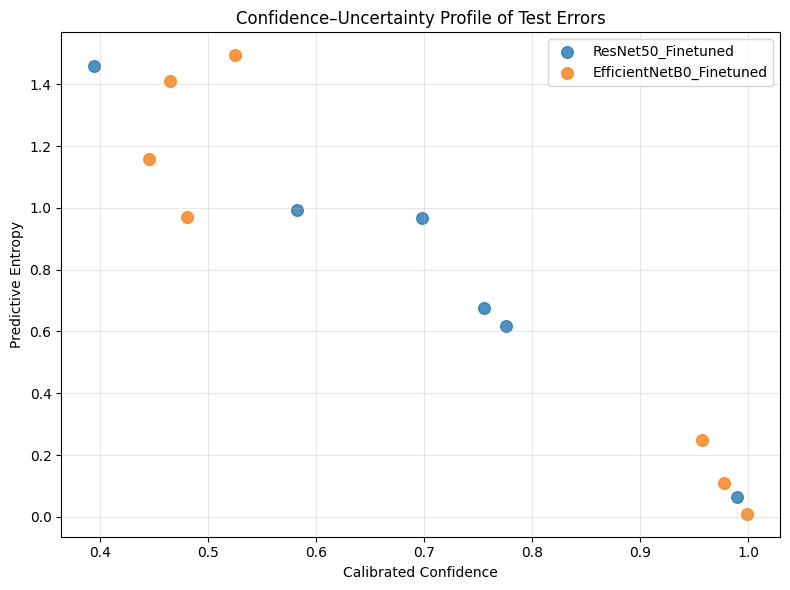

✅ Saved: /kaggle/working/phaseI_error_confidence_vs_entropy.png


In [14]:
# ============================================================
# CELL 14 — FIGURE 1: ERROR CONFIDENCE VS ENTROPY
# ============================================================

plt.figure(
    figsize=(8, 6)
)

for model_name in MODEL_NAMES:
    temp = unified_errors[
        unified_errors["Model"]
        == model_name
    ]

    plt.scatter(
        temp[
            "calibrated_confidence"
        ],
        temp[
            "predictive_entropy"
        ],
        s=70,
        alpha=0.8,
        label=model_name
    )

plt.xlabel(
    "Calibrated Confidence"
)

plt.ylabel(
    "Predictive Entropy"
)

plt.title(
    "Confidence–Uncertainty Profile of Test Errors"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

ERROR_SCATTER_PATH = (
    "/kaggle/working/"
    "phaseI_error_confidence_vs_entropy.png"
)

plt.savefig(
    ERROR_SCATTER_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "✅ Saved:",
    ERROR_SCATTER_PATH
)


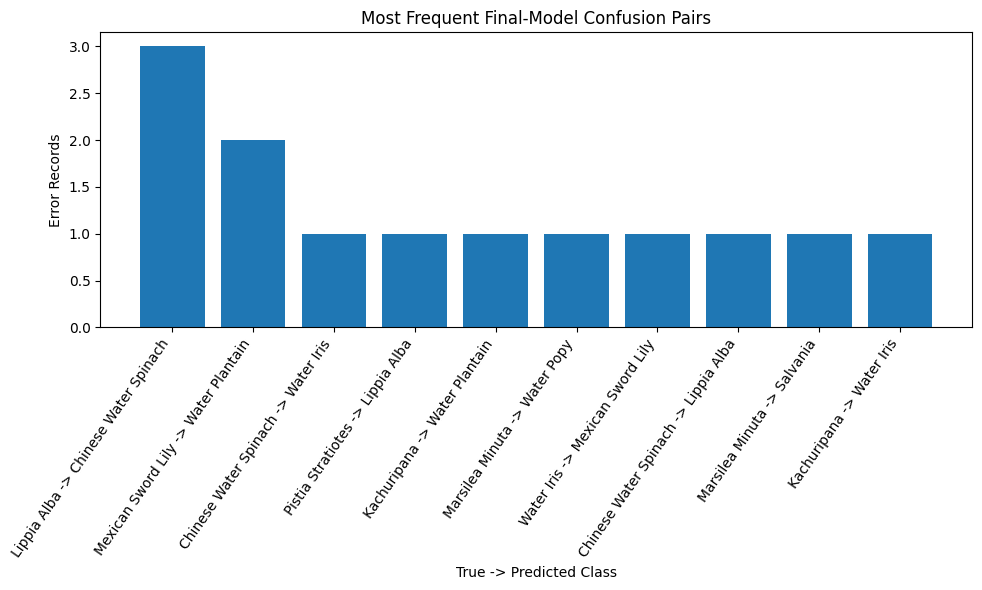

✅ Saved: /kaggle/working/phaseI_top_confusion_pairs.png


In [15]:
# ============================================================
# CELL 15 — FIGURE 2: MOST FREQUENT CONFUSION PAIRS
# ============================================================

top_confusions = (
    confusion_summary
    .head(10)
    .copy()
)

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    top_confusions[
        "confusion_pair"
    ],
    top_confusions[
        "error_count"
    ]
)

plt.xlabel(
    "True -> Predicted Class"
)

plt.ylabel(
    "Error Records"
)

plt.title(
    "Most Frequent Final-Model Confusion Pairs"
)

plt.xticks(
    rotation=55,
    ha="right"
)

plt.tight_layout()

CONFUSION_PLOT_PATH = (
    "/kaggle/working/"
    "phaseI_top_confusion_pairs.png"
)

plt.savefig(
    CONFUSION_PLOT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "✅ Saved:",
    CONFUSION_PLOT_PATH
)


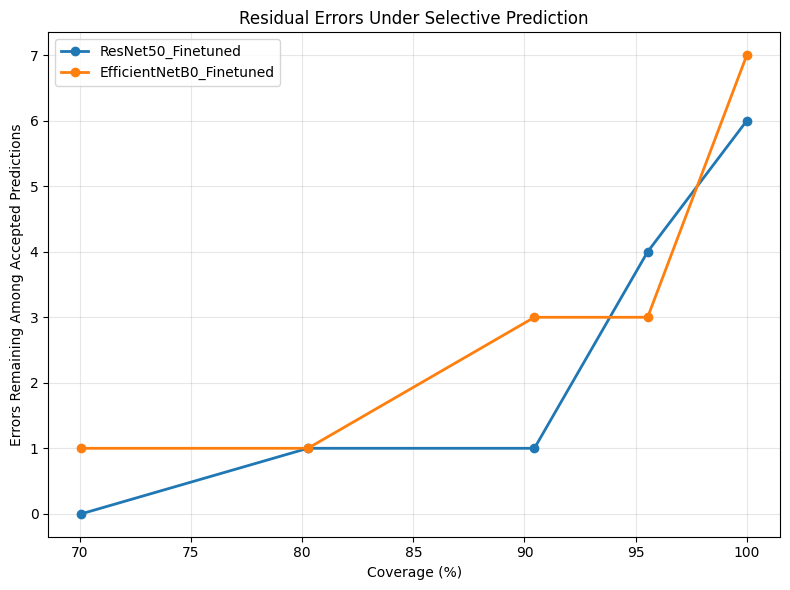

✅ Saved: /kaggle/working/phaseI_error_survival_vs_coverage.png


In [16]:
# ============================================================
# CELL 16 — FIGURE 3: ERRORS SURVIVING SELECTIVE PREDICTION
# ============================================================

plt.figure(
    figsize=(8, 6)
)

for model_name in MODEL_NAMES:
    temp = error_survival_df[
        error_survival_df["Model"]
        == model_name
    ]

    plt.plot(
        temp[
            "Actual Coverage (%)"
        ],
        temp[
            "Accepted Errors"
        ],
        marker="o",
        linewidth=2,
        label=model_name
    )

plt.xlabel(
    "Coverage (%)"
)

plt.ylabel(
    "Errors Remaining Among Accepted Predictions"
)

plt.title(
    "Residual Errors Under Selective Prediction"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

SURVIVAL_PLOT_PATH = (
    "/kaggle/working/"
    "phaseI_error_survival_vs_coverage.png"
)

plt.savefig(
    SURVIVAL_PLOT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "✅ Saved:",
    SURVIVAL_PLOT_PATH
)


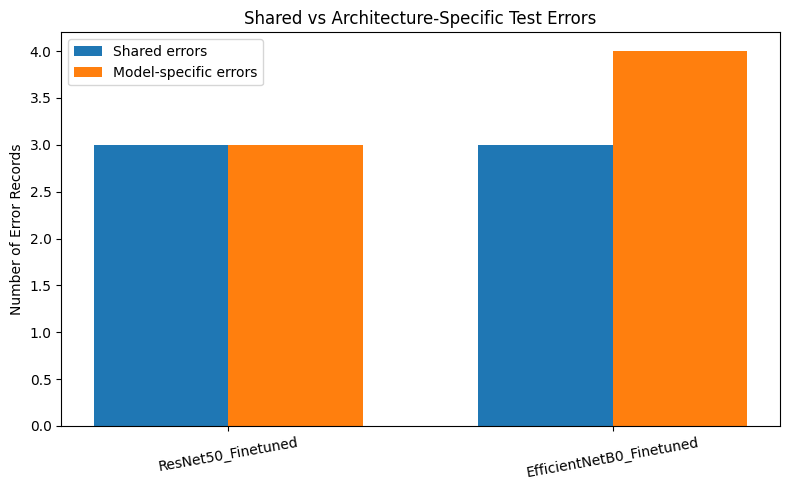

✅ Saved: /kaggle/working/phaseI_shared_vs_model_specific_errors.png


In [17]:
# ============================================================
# CELL 17 — FIGURE 4: SHARED VS MODEL-SPECIFIC ERRORS
# ============================================================

shared_unique_rows = []

for model_name in MODEL_NAMES:
    temp = unified_errors[
        unified_errors["Model"]
        == model_name
    ]

    shared_count = int(
        temp[
            "shared_error_across_models"
        ].sum()
    )

    unique_count = (
        len(temp)
        - shared_count
    )

    shared_unique_rows.append({
        "Model":
            model_name,

        "Shared errors":
            shared_count,

        "Model-specific errors":
            unique_count,
    })

shared_unique_df = pd.DataFrame(
    shared_unique_rows
)

x = np.arange(
    len(
        shared_unique_df
    )
)

width = 0.35

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    x - width / 2,
    shared_unique_df[
        "Shared errors"
    ],
    width,
    label="Shared errors"
)

plt.bar(
    x + width / 2,
    shared_unique_df[
        "Model-specific errors"
    ],
    width,
    label="Model-specific errors"
)

plt.xticks(
    x,
    shared_unique_df[
        "Model"
    ],
    rotation=10
)

plt.ylabel(
    "Number of Error Records"
)

plt.title(
    "Shared vs Architecture-Specific Test Errors"
)

plt.legend()

plt.tight_layout()

SHARED_UNIQUE_PLOT_PATH = (
    "/kaggle/working/"
    "phaseI_shared_vs_model_specific_errors.png"
)

plt.savefig(
    SHARED_UNIQUE_PLOT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "✅ Saved:",
    SHARED_UNIQUE_PLOT_PATH
)


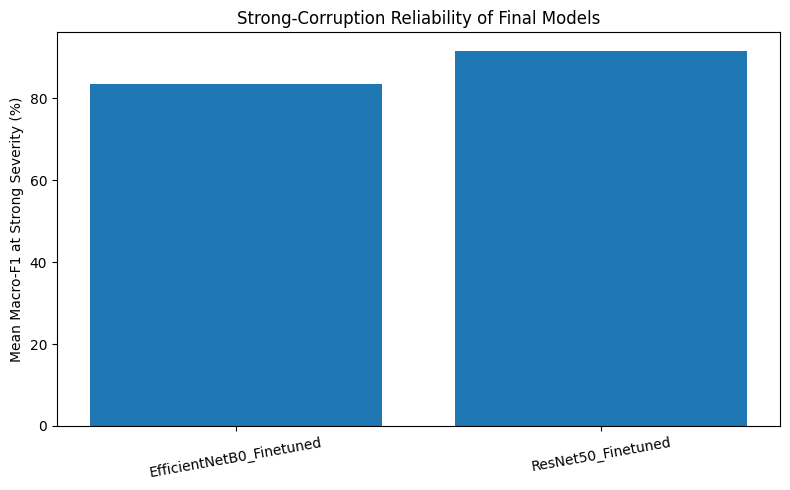

✅ Saved: /kaggle/working/phaseI_strong_corruption_comparison.png


In [18]:
# ============================================================
# CELL 18 — FIGURE 5: STRONG-CORRUPTION ROBUSTNESS
# ============================================================

strong_plot_df = (
    E_strong[
        E_strong["Model"]
        .isin(
            MODEL_NAMES
        )
    ]
    .copy()
)

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    strong_plot_df[
        "Model"
    ],
    strong_plot_df[
        "Macro-F1 (%)"
    ]
)

plt.ylabel(
    "Mean Macro-F1 at Strong Severity (%)"
)

plt.title(
    "Strong-Corruption Reliability of Final Models"
)

plt.xticks(
    rotation=10
)

plt.tight_layout()

STRONG_ROBUSTNESS_PATH = (
    "/kaggle/working/"
    "phaseI_strong_corruption_comparison.png"
)

plt.savefig(
    STRONG_ROBUSTNESS_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "✅ Saved:",
    STRONG_ROBUSTNESS_PATH
)


In [19]:
# ============================================================
# CELL 19 — AUTOMATIC KEY FINDINGS
# ============================================================

# Most frequent confusion pair.
top_pair = (
    confusion_summary
    .iloc[0]
)

# Strong-corruption winner.
strong_best = (
    E_strong
    .sort_values(
        "Macro-F1 (%)",
        ascending=False
    )
    .iloc[0]
)

# Lowest calibrated ECE.
ece_best = (
    F_calibration
    .sort_values(
        "ECE After",
        ascending=True
    )
    .iloc[0]
)

# Lowest confidence AURC.
aurc_primary = G_aurc[
    G_aurc[
        "Uncertainty Score"
    ] == "Calibrated confidence"
].copy()

aurc_best = (
    aurc_primary
    .sort_values(
        "AURC",
        ascending=True
    )
    .iloc[0]
)

high_conf_counts = (
    unified_errors
    .assign(
        high_conf=lambda df: (
            df[
                "calibrated_confidence"
            ]
            >= HIGH_CONF_THRESHOLD
        )
    )
    .groupby(
        "Model"
    )["high_conf"]
    .sum()
    .to_dict()
)

survive90_counts = (
    unified_errors
    .groupby(
        "Model"
    )[
        "accepted_at_90pct_coverage"
    ]
    .sum()
    .to_dict()
)

finding_lines = [
    "PHASE I — KEY FINDINGS",
    "=" * 70,
    "",
    (
        f"1. Shared hard Test images across both final models: "
        f"{len(shared_image_keys)}."
    ),
    (
        f"2. Most frequent confusion pair: "
        f"{top_pair['confusion_pair']} "
        f"({int(top_pair['error_count'])} model-error records)."
    ),
    (
        f"3. High-confidence errors (calibrated confidence >= 0.95): "
        f"ResNet50={int(high_conf_counts.get('ResNet50_Finetuned', 0))}, "
        f"EfficientNet-B0={int(high_conf_counts.get('EfficientNetB0_Finetuned', 0))}."
    ),
    (
        f"4. Errors surviving approximately 90% coverage: "
        f"ResNet50={int(survive90_counts.get('ResNet50_Finetuned', 0))}, "
        f"EfficientNet-B0={int(survive90_counts.get('EfficientNetB0_Finetuned', 0))}."
    ),
    (
        f"5. Strong-corruption robustness leader: "
        f"{strong_best['Model']} "
        f"(Macro-F1={strong_best['Macro-F1 (%)']:.2f}%)."
    ),
    (
        f"6. Lowest post-calibration ECE: "
        f"{ece_best['Model']} "
        f"(ECE={ece_best['ECE After']:.4f})."
    ),
    (
        f"7. Best confidence-based selective ranking: "
        f"{aurc_best['Model']} "
        f"(AURC={aurc_best['AURC']:.6f})."
    ),
    "",
    (
        "Interpretation: many errors are uncertainty-detectable and can be "
        "rejected through selective prediction, but a smaller set of "
        "high-confidence/shared hard cases remain important residual risks."
    ),
    (
        "Grad-CAM descriptors are qualitative/descriptive support only; "
        "they are not localization accuracy."
    ),
]

KEY_FINDINGS_PATH = (
    "/kaggle/working/"
    "phaseI_key_findings.txt"
)

with open(
    KEY_FINDINGS_PATH,
    "w"
) as f:
    f.write(
        "\n".join(
            finding_lines
        )
    )

print(
    "\n".join(
        finding_lines
    )
)

print(
    "\n✅ Saved:",
    KEY_FINDINGS_PATH
)


PHASE I — KEY FINDINGS

1. Shared hard Test images across both final models: 3.
2. Most frequent confusion pair: Lippia Alba -> Chinese Water Spinach (3 model-error records).
3. High-confidence errors (calibrated confidence >= 0.95): ResNet50=1, EfficientNet-B0=3.
4. Errors surviving approximately 90% coverage: ResNet50=1, EfficientNet-B0=3.
5. Strong-corruption robustness leader: ResNet50_Finetuned (Macro-F1=91.52%).
6. Lowest post-calibration ECE: ResNet50_Finetuned (ECE=0.0300).
7. Best confidence-based selective ranking: ResNet50_Finetuned (AURC=0.003375).

Interpretation: many errors are uncertainty-detectable and can be rejected through selective prediction, but a smaller set of high-confidence/shared hard cases remain important residual risks.
Grad-CAM descriptors are qualitative/descriptive support only; they are not localization accuracy.

✅ Saved: /kaggle/working/phaseI_key_findings.txt


In [20]:
# ============================================================
# CELL 20 — PHASE I METADATA
# ============================================================

phaseI_metadata = {
    "phase":
        "Phase I — Integrated Failure & Reliability Analysis",

    "integrated_phases": [
        "Phase D — Locked Test Evaluation",
        "Phase E — Corruption Robustness",
        "Phase F — Calibration & Uncertainty",
        "Phase G — Selective Prediction",
        "Phase H — Grad-CAM Explainability",
    ],

    "test_images":
        EXPECTED_TEST_IMAGES,

    "models":
        MODEL_NAMES,

    "model_training_performed":
        False,

    "model_tuning_performed":
        False,

    "new_model_inference_performed":
        False,

    "high_confidence_error_threshold":
        HIGH_CONF_THRESHOLD,

    "moderate_confidence_threshold":
        MODERATE_CONF_THRESHOLD,

    "selective_coverage_levels":
        COVERAGE_LEVELS,

    "shared_error_definition":
        (
            "The same locked-Test image is "
            "misclassified by both final models."
        ),

    "recurrent_confusion_definition":
        (
            "A true-to-predicted class pair occurs "
            "at least twice across final-model error records."
        ),

    "gradcam_interpretation":
        (
            "Grad-CAM concentration is descriptive only; "
            "no localization ground truth is used and "
            "no localization accuracy is claimed."
        ),

    "test_threshold_optimization_performed":
        False,

    "purpose":
        (
            "Integrate clean error patterns, corruption robustness, "
            "calibration, selective prediction, and Grad-CAM evidence "
            "into a final reliability-oriented failure analysis."
        ),
}

METADATA_PATH = (
    "/kaggle/working/"
    "phaseI_metadata.json"
)

with open(
    METADATA_PATH,
    "w"
) as f:
    json.dump(
        phaseI_metadata,
        f,
        indent=2
    )

print(
    json.dumps(
        phaseI_metadata,
        indent=2
    )
)

print(
    "\n✅ Saved:",
    METADATA_PATH
)


{
  "phase": "Phase I \u2014 Integrated Failure & Reliability Analysis",
  "integrated_phases": [
    "Phase D \u2014 Locked Test Evaluation",
    "Phase E \u2014 Corruption Robustness",
    "Phase F \u2014 Calibration & Uncertainty",
    "Phase G \u2014 Selective Prediction",
    "Phase H \u2014 Grad-CAM Explainability"
  ],
  "test_images": 157,
  "models": [
    "ResNet50_Finetuned",
    "EfficientNetB0_Finetuned"
  ],
  "model_training_performed": false,
  "model_tuning_performed": false,
  "new_model_inference_performed": false,
  "high_confidence_error_threshold": 0.95,
  "moderate_confidence_threshold": 0.8,
  "selective_coverage_levels": [
    1.0,
    0.95,
    0.9,
    0.8,
    0.7
  ],
  "shared_error_definition": "The same locked-Test image is misclassified by both final models.",
  "recurrent_confusion_definition": "A true-to-predicted class pair occurs at least twice across final-model error records.",
  "gradcam_interpretation": "Grad-CAM concentration is descriptive onl

In [21]:
# ============================================================
# CELL 21 — FINAL PHASE-I ARTIFACT ZIP
# ============================================================

PHASE_I_ZIP = (
    "/kaggle/working/"
    "AquaPlant_PhaseI_Integrated_Failure_Analysis_Artifacts.zip"
)

files_to_backup = []

for filename in os.listdir(
    "/kaggle/working"
):
    full_path = os.path.join(
        "/kaggle/working",
        filename
    )

    if not os.path.isfile(
        full_path
    ):
        continue

    if filename.startswith(
        "phaseI_"
    ) and filename.lower().endswith(
        (
            ".csv",
            ".png",
            ".json",
            ".txt",
        )
    ):
        files_to_backup.append(
            full_path
        )

with zipfile.ZipFile(
    PHASE_I_ZIP,
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:
    for file_path in files_to_backup:
        zipf.write(
            file_path,
            arcname=os.path.basename(
                file_path
            )
        )

with zipfile.ZipFile(
    PHASE_I_ZIP,
    "r"
) as zipf:
    bad_file = zipf.testzip()
    contents = zipf.namelist()

assert bad_file is None

print("=" * 82)
print("PHASE I FINAL BACKUP")
print("=" * 82)

print("\nZIP:")
print(PHASE_I_ZIP)

print(
    "\nFiles included:",
    len(contents)
)

for item in sorted(
    contents
):
    print(
        " -",
        item
    )

print(
    "\nZIP size:",
    f"{os.path.getsize(PHASE_I_ZIP) / (1024 ** 2):.2f} MB"
)

print(
    "\n✅ ZIP integrity check PASSED"
)

print(
    "✅ PHASE I INTEGRATED FAILURE ANALYSIS COMPLETE"
)

print(
    "✅ ALL PLANNED EXPERIMENTAL PHASES A–I ARE COMPLETE"
)

print(
    "✅ Download "
    "AquaPlant_PhaseI_Integrated_Failure_Analysis_Artifacts.zip"
)


PHASE I FINAL BACKUP

ZIP:
/kaggle/working/AquaPlant_PhaseI_Integrated_Failure_Analysis_Artifacts.zip

Files included: 14
 - phaseI_confusion_pair_summary.csv
 - phaseI_cross_phase_model_profile.csv
 - phaseI_error_confidence_vs_entropy.png
 - phaseI_error_survival_by_coverage.csv
 - phaseI_error_survival_vs_coverage.png
 - phaseI_failure_taxonomy_summary.csv
 - phaseI_key_findings.txt
 - phaseI_metadata.json
 - phaseI_priority_failure_cases.csv
 - phaseI_shared_cross_model_errors.csv
 - phaseI_shared_vs_model_specific_errors.png
 - phaseI_strong_corruption_comparison.png
 - phaseI_top_confusion_pairs.png
 - phaseI_unified_error_table.csv

ZIP size: 0.76 MB

✅ ZIP integrity check PASSED
✅ PHASE I INTEGRATED FAILURE ANALYSIS COMPLETE
✅ ALL PLANNED EXPERIMENTAL PHASES A–I ARE COMPLETE
✅ Download AquaPlant_PhaseI_Integrated_Failure_Analysis_Artifacts.zip


# Phase-I interpretation guide

The final discussion should distinguish between three types of evidence:

### 1. Quantitative evidence
Examples:
- locked-Test accuracy / Macro-F1
- strong-corruption Macro-F1
- ECE / NLL / Brier
- AURC
- error-rejection rates

### 2. Per-error reliability evidence
Examples:
- calibrated confidence
- predictive entropy
- whether the error is rejected at ~90% coverage
- whether both architectures fail on the same image
- recurrent true-to-predicted class confusions

### 3. Explainability evidence
Grad-CAM is used only as **qualitative/descriptive support**.

Good wording:

> “The integrated failure analysis showed that most residual errors were identifiable through elevated uncertainty and selective rejection, whereas a smaller subset of shared or high-confidence errors remained challenging. Recurrent confusion between visually similar categories and common cross-model failures indicate that some errors arise from difficult visual evidence rather than architecture-specific instability.”

Avoid:
- calling Test-derived thresholds “optimal”
- claiming Grad-CAM proves causal feature use
- claiming CAM concentration is localization accuracy
- claiming complete robustness under all real-world conditions